**Project Name:** Traffic Accident Analysis

**Project Type:** EDA

**Contribution:** Individual

**Github Link**: [link text](https://)



**Project Summary:**

In this project, I analyzed traffic accident data using EDA techniques.
I cleaned the data, handled missing values, and created visualizations to understand patterns.

From the analysis, I found that most accidents are caused by factors like driver behavior, road conditions, and weather.
This project helps in understanding how accidents occur and how we can improve road safety.


**Problem Statement:**

Road accidents are a major public safety issue, leading to injuries, loss of life, and economic damage. However, understanding the key factors that contribute to accidents—such as driver behavior, road conditions, weather, and time—is challenging due to complex and large datasets.

**1. Know Your Data**

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
path="/content/drive/MyDrive/Road.csv"




Mounted at /content/drive


In [ ]:
df = pd.read_csv(path)

df_clean = df.copy()

print(df.columns.tolist())
print(df_clean.columns.tolist())
print(len(df_clean.columns.tolist()))

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surfac

In [ ]:
#Dataset first view
print("First 5 rows in the dataset: \n")
df_clean.head()


First 5 rows in the dataset: 



,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


Dataset rows and columns count

In [ ]:
num_rows, num_columns=df_clean.shape

print("Number of rows: ",num_rows)
print("Number of columns: ",num_columns)

Number of rows:  12316
Number of columns:  32


Dataset Information

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

Duplicated values

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

Missing values

In [ ]:
df_clean.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


Visualising missing values

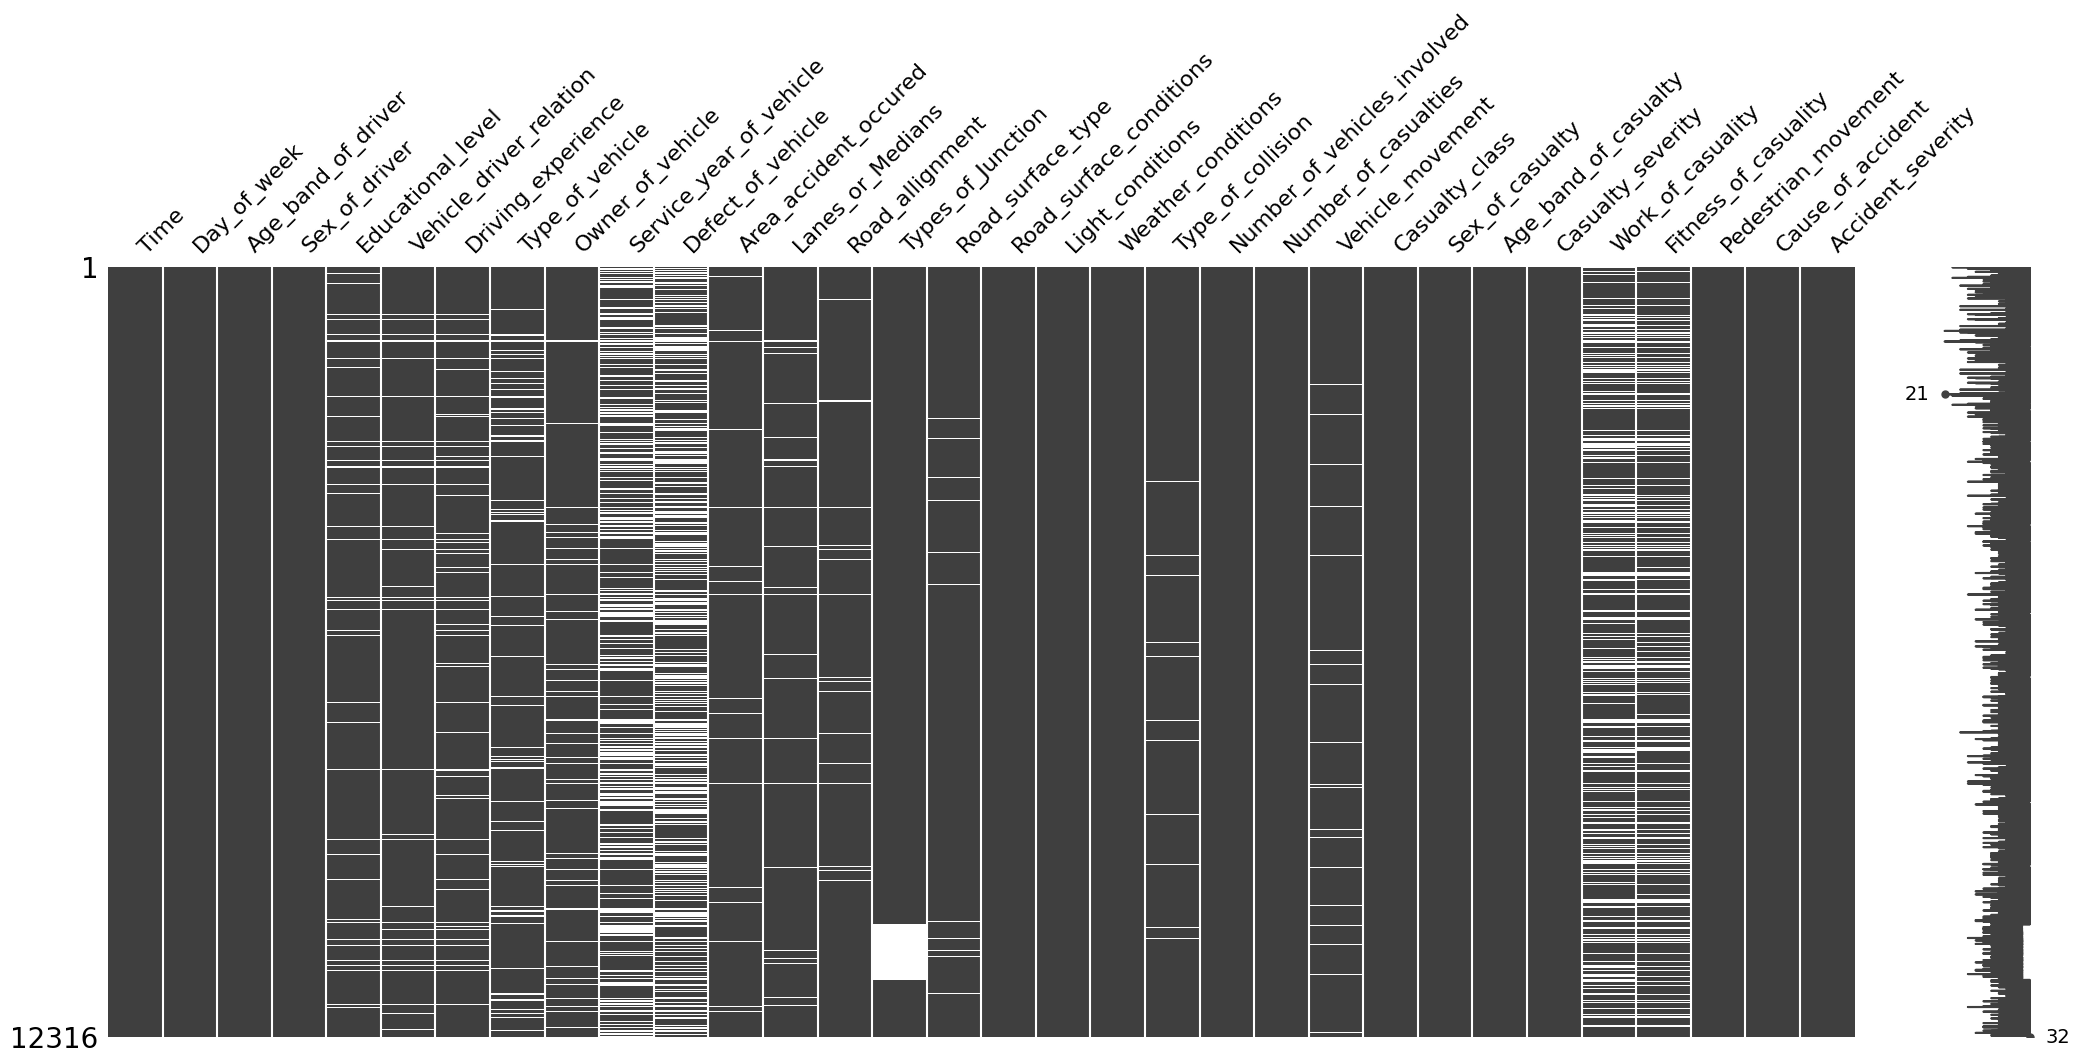

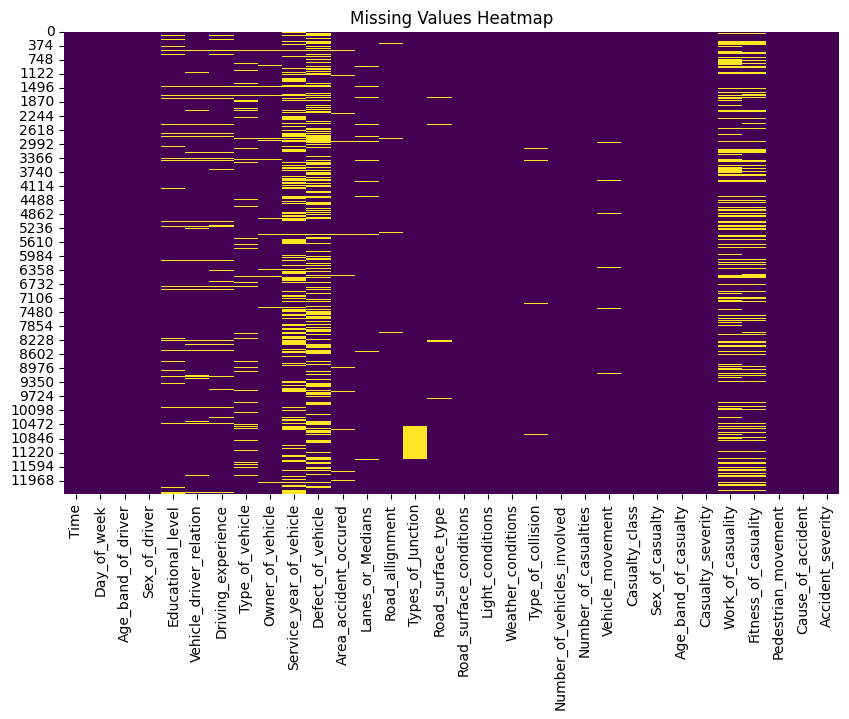

In [ ]:
#missingo matrix
msno.matrix(df_clean)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap='viridis',cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


What did you know about your dataset ?

**2. Understanding Your Variables**

In [ ]:
#Dataset columns
print("Columns present in the dataset: \n")
print(df_clean.columns)

print("\n Data types of columns of the dataset: \n")
print(df_clean.dtypes)

Columns present in the dataset: 

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

 Data types of columns of the dataset: 

Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver               

Dataset Describe

In [ ]:
print("Description of the dataset: \n")
df_clean.describe()

Description of the dataset: 



,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


Variables Description

The dataset contains information related to traffic accidents, including driver details, vehicle information, road conditions, environmental factors, and accident outcomes.

Time & Day: Show when the accident occurred.

Driver Details: Age, gender, education, and driving experience of the driver

Vehicle Details: Type, ownership, age, and condition of the vehicle.

Road & Location: Area, road type, alignment, and junction details.

Environmental Factors: Weather, lighting, and road surface conditions.

Accident Details: Type of collision, number of vehicles, and casualties.

Casualty Information: Details about people affected in the accident.

Cause & Movement: Behavior of vehicle/pedestrian and cause of accident.

Target Variable: Accident_severity, which shows how severe the accident is.

In [ ]:
#check unique value for each variable
print("Unique values in each column of the dataset: \n")
print(df_clean.nunique())

Unique values in each column of the dataset: 

Time                           1074
Day_of_week                       7
Age_band_of_driver                5
Sex_of_driver                     3
Educational_level                 7
Vehicle_driver_relation           4
Driving_experience                7
Type_of_vehicle                  17
Owner_of_vehicle                  4
Service_year_of_vehicle           6
Defect_of_vehicle                 3
Area_accident_occured            14
Lanes_or_Medians                  7
Road_allignment                   9
Types_of_Junction                 8
Road_surface_type                 5
Road_surface_conditions           4
Light_conditions                  4
Weather_conditions                9
Type_of_collision                10
Number_of_vehicles_involved       6
Number_of_casualties              8
Vehicle_movement                 13
Casualty_class                    4
Sex_of_casualty                   3
Age_band_of_casualty              6
Casualty_severity

**3. Data Wrangling**

1. Remove exact duplicates

In [ ]:
print("Checking for duplicate rows...\n")
print("Duplicates found: ",df_clean.duplicated().sum())

df_clean.drop_duplicates(inplace=True)
print("Shape after removing duplicates: ",df_clean.shape)


Checking for duplicate rows...

Duplicates found:  0
Shape after removing duplicates:  (12316, 32)


2. Fixing inconsistent entries

In [ ]:
print("Fixing inconsistent entries...\n")

# Standardize column names
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Fix Weather conditions
df_clean['weather_conditions'] = df_clean['weather_conditions'].replace({
    'rainy': 'rain',
    'raining': 'rain',
    'clear sky': 'clear',
    'snowy': 'snow'
})

# Fix Road surface conditions
df_clean['road_surface_conditions'] = df_clean['road_surface_conditions'].replace({
    'dry road': 'dry',
    'wet road': 'wet'
})

# Fix Light conditions
df_clean['light_conditions'] = df_clean['light_conditions'].replace({
    'day light': 'daylight',
    'darkness - lights lit': 'dark_light',
    'darkness - no lighting': 'dark_no_light'
})

# Fix Type of vehicle
df_clean['type_of_vehicle'] = df_clean['type_of_vehicle'].replace({
    'automobile': 'car',
    'lorrie': 'truck'
})

# Remove extra spaces
df_clean = df_clean.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Convert all text to lowercase
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.lower()


Fixing inconsistent entries...



3.Handling missing values

In [ ]:
print("Missing values before handling:\n")
print(df_clean.isnull().sum())
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
for col in df_clean.select_dtypes(include=['int64','float64']).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
print("Missing values after handling:\n")
print(df_clean.isnull().sum())

Missing values before handling:

time                              0
day_of_week                       0
age_band_of_driver                0
sex_of_driver                     0
educational_level               741
vehicle_driver_relation         579
driving_experience              829
type_of_vehicle                 950
owner_of_vehicle                482
service_year_of_vehicle        3928
defect_of_vehicle              4427
area_accident_occured           239
lanes_or_medians                385
road_allignment                 142
types_of_junction               887
road_surface_type               172
road_surface_conditions           0
light_conditions                  0
weather_conditions                0
type_of_collision               155
number_of_vehicles_involved       0
number_of_casualties              0
vehicle_movement                308
casualty_class                    0
sex_of_casualty                   0
age_band_of_casualty              0
casualty_severity              

4.Detect and treat outliers

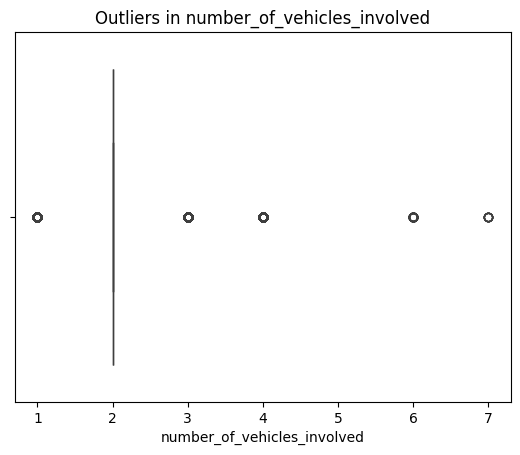

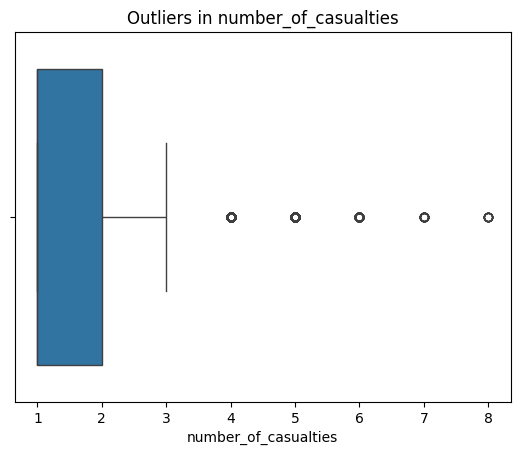

In [ ]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [ ]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df_clean[col].median()

    # Replace outliers with median
    df_clean[col] = np.where((df_clean[col] < lower) | (df_clean[col] > upper),
                            median,
                            df_clean[col])

print("Outliers replaced with median successfully!")


Outliers replaced with median successfully!


5.Scaling and normalisation

In [ ]:
print("Scaling numerical features")
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

#Apply Standard Scaling
scaler = MinMaxScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

Scaling numerical features


6.Encoding categorical data

In [ ]:
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean = pd.get_dummies(df_clean,
                          columns=cat_cols,
                          drop_first=True)

7.Feature engineering

In [ ]:
print("Performing feature engineering...\n")

df_clean.columns = df_clean.columns.str.strip().str.lower()

# Convert time column to datetime
if 'time' in df_clean.columns:
    df_clean['time'] = pd.to_datetime(df_clean['time'], errors='coerce')
    df_clean['hour'] = df_clean['time'].dt.hour

# Create time of day feature
if 'hour' in df_clean.columns:
    df_clean['time_of_day'] = df_clean['hour'].apply(
        lambda x: 'day' if pd.notnull(x) and 6 <= x <= 18 else 'night'
    )

# Create age group
if 'age_of_driver' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age_of_driver'],
                                  bins=[0, 25, 60, 100],
                                  labels=['young', 'adult', 'senior'])

# Create severity binary
if 'accident_severity' in df_clean.columns:
    df_clean['severity_binary'] = df_clean['accident_severity'].apply(
        lambda x: 1 if str(x).lower() == 'fatal' else 0
    )

# Create casualty level
if 'number_of_casualties' in df_clean.columns:
    df_clean['casualty_level'] = pd.cut(df_clean['number_of_casualties'],
                                       bins=[0, 2, 5, 100],
                                       labels=['low', 'medium', 'high'])

# Create speed category
if 'speed_limit' in df_clean.columns:
    df_clean['speed_category'] = pd.cut(df_clean['speed_limit'],
                                        bins=[0, 40, 80, 200],
                                        labels=['low', 'medium', 'high'])

print("Feature engineering completed successfully.\n")

Performing feature engineering...

Feature engineering completed successfully.



8.Drop unnecessary columns

In [ ]:
cols_to_drop = [] # Define cols_to_drop as an empty list, you can add column names here if needed

print("Preparing to drop unnecessary columns...")

columns_to_drop_final = []

# Add explicitly defined columns to drop, if they exist
for col in cols_to_drop:
    if col in df_clean.columns:
        columns_to_drop_final.append(col)

# Add the original 'time' column if it exists
if 'time' in df_clean.columns:
    columns_to_drop_final.append('time')

# Add all one-hot encoded time columns (e.g., 'time_0:00:00')
time_cols_to_remove = [col for col in df_clean.columns if col.startswith('time_')]
columns_to_drop_final.extend(time_cols_to_remove)

# Drop all identified columns in one go, using a set to handle potential duplicates
if columns_to_drop_final:
    unique_cols_to_drop = list(set(columns_to_drop_final))
    df_clean.drop(columns=unique_cols_to_drop, inplace=True)
    print(f"Dropped {len(unique_cols_to_drop)} unnecessary columns.")
else:
    print("No additional unnecessary columns found to drop.")

print("Remaining columns:\n", df_clean.columns.tolist())
print("\nUnnecessary columns dropped successfully.")

Preparing to drop unnecessary columns...
Dropped 1073 unnecessary columns.
Remaining columns:
 ['number_of_vehicles_involved', 'number_of_casualties', 'day_of_week_monday', 'day_of_week_saturday', 'day_of_week_sunday', 'day_of_week_thursday', 'day_of_week_tuesday', 'day_of_week_wednesday', 'age_band_of_driver_31-50', 'age_band_of_driver_over 51', 'age_band_of_driver_under 18', 'age_band_of_driver_unknown', 'sex_of_driver_male', 'sex_of_driver_unknown', 'educational_level_elementary school', 'educational_level_high school', 'educational_level_illiterate', 'educational_level_junior high school', 'educational_level_unknown', 'educational_level_writing & reading', 'vehicle_driver_relation_other', 'vehicle_driver_relation_owner', 'vehicle_driver_relation_unknown', 'driving_experience_2-5yr', 'driving_experience_5-10yr', 'driving_experience_above 10yr', 'driving_experience_below 1yr', 'driving_experience_no licence', 'driving_experience_unknown', 'type_of_vehicle_bajaj', 'type_of_vehicle_bic

Data visualisation

chart-1: Distribution of Vehicles Involved in Accidents

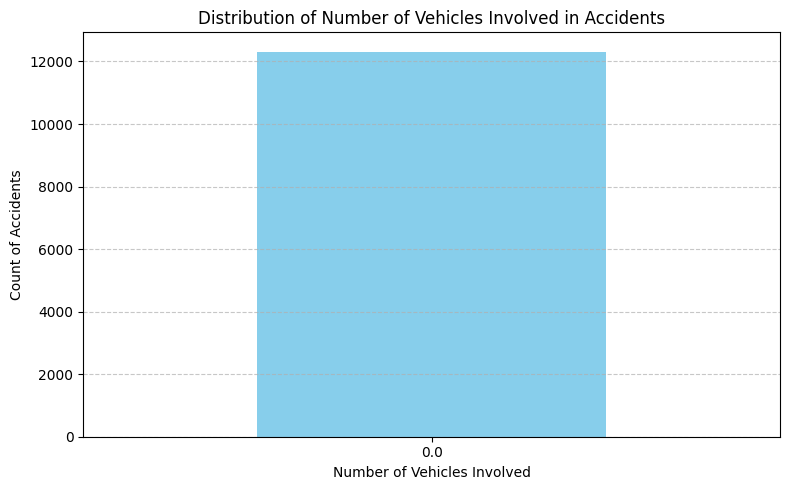

In [ ]:
plt.figure(figsize=(8, 5))
df_clean['number_of_vehicles_involved'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Distribution of Number of Vehicles Involved in Accidents")
plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Count of Accidents")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 1:
- The majority of accidents involve 1 or 2 vehicles.
- The frequency of accidents decreases significantly as the number of vehicles involved increases.

chart-2: Top 10 Vehicle Types Involved in Accidents

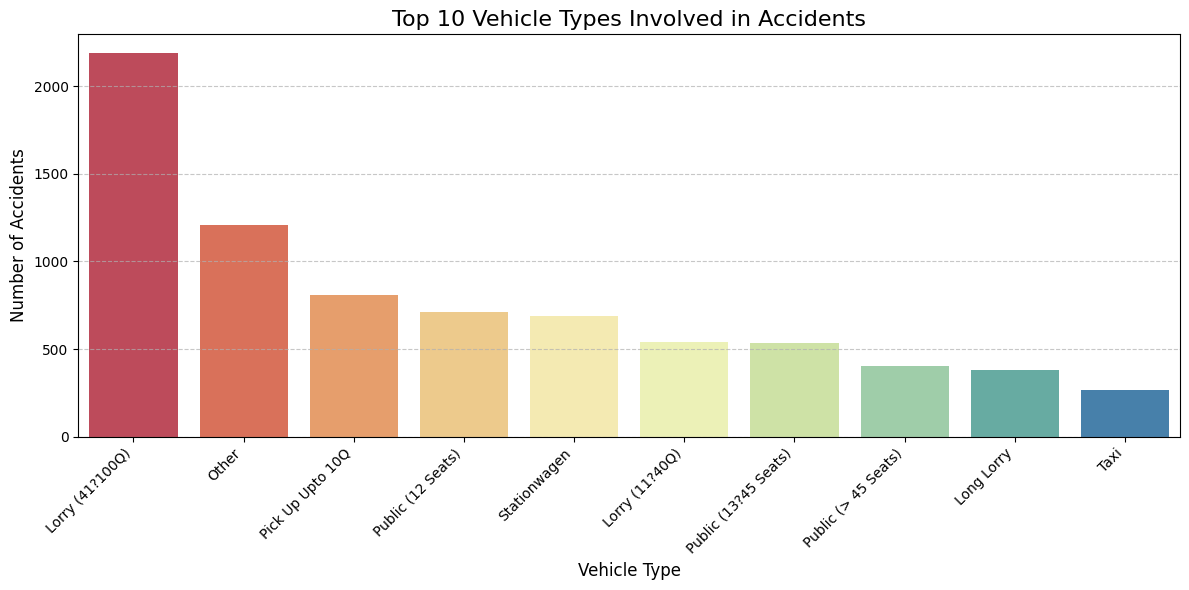

In [ ]:
vehicle_cols = [col for col in df_clean.columns if col.startswith('type_of_vehicle_')]
vehicle_counts = df_clean[vehicle_cols].sum().sort_values(ascending=False).head(10)
vehicle_counts.index = [col.replace('type_of_vehicle_', '').replace('_', ' ').title() for col in vehicle_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=vehicle_counts.index, y=vehicle_counts.values, palette='Spectral')
plt.title('Top 10 Vehicle Types Involved in Accidents', fontsize=16)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 2:
- Most accidents involve lorries, particularly those in the 41-100q category.
- Public transport vehicles are also frequently involved in accidents.

chart-3: Accidents by Day of Week

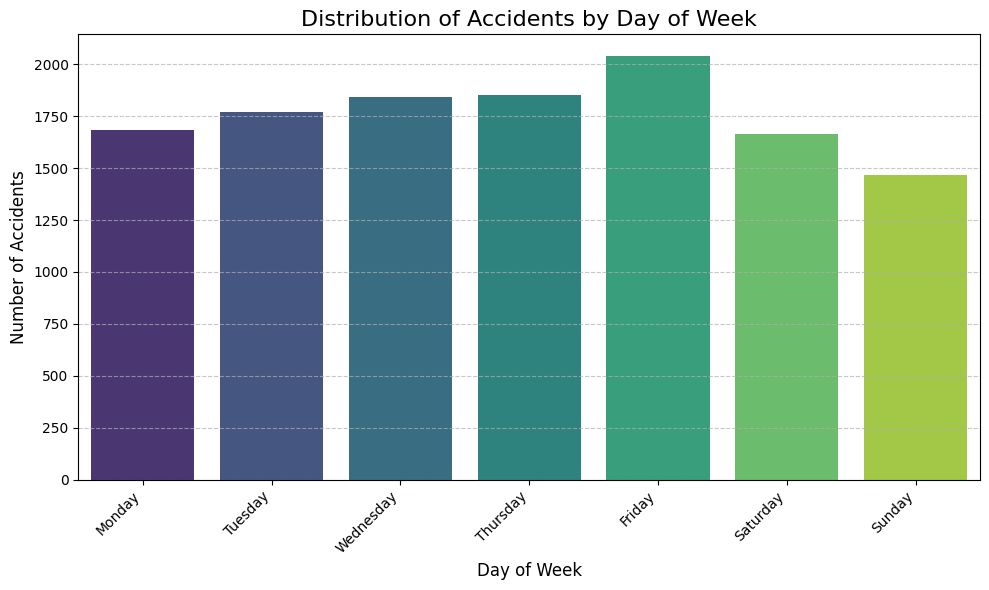

In [ ]:
day_cols = [col for col in df_clean.columns if col.startswith('day_of_week_')]

# Initialize a dictionary to store counts for all days
full_day_counts = {}

# Get counts for explicitly present day columns
for col in day_cols:
    day_name = col.replace('day_of_week_', '').title()
    full_day_counts[day_name] = df_clean[col].sum()

# Identify the dropped column (assuming it's 'Friday') by summing all other day columns.
# If the sum is 0, it means that row corresponds to the dropped category.
other_days_sum = df_clean[day_cols].sum(axis=1)
dropped_day_count = (other_days_sum == 0).sum()

# Assign this count to 'Friday'
full_day_counts['Friday'] = dropped_day_count

# Define the desired order of days
ordered_day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert to Series and reindex to ensure the correct order
day_counts_ordered = pd.Series(full_day_counts).reindex(ordered_day_names).fillna(0)

plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts_ordered.index, y=day_counts_ordered.values, palette='viridis')
plt.title('Distribution of Accidents by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 3:
-   Fridays and Thursdays have the highest number of accidents.
-   Weekends (Saturday and Sunday) show a lower number of accidents compared to weekdays.

chart-4: Accidents by Weather Conditions

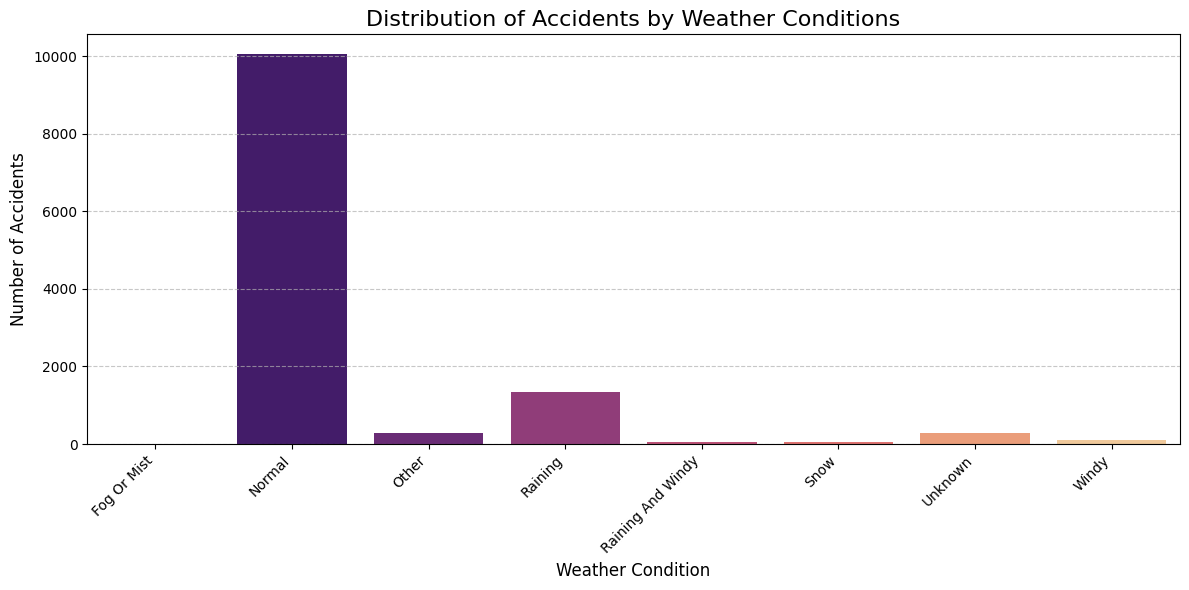

In [ ]:
weather_cols = [col for col in df_clean.columns if col.startswith('weather_conditions_')]
weather_counts = df_clean[weather_cols].sum()
weather_counts.index = [col.replace('weather_conditions_', '').replace('_', ' ').title() for col in weather_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=weather_counts.index, y=weather_counts.values, palette='magma')
plt.title('Distribution of Accidents by Weather Conditions', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 4:
-   The vast majority of accidents occur under normal weather conditions.
-   Accidents during rainy conditions are the second most common, highlighting the impact of rain on road safety.
-   Other severe weather conditions like fog, snow, or wind contribute to a very small fraction of total accidents.

chart-5: Accidents by Age Band of Driver

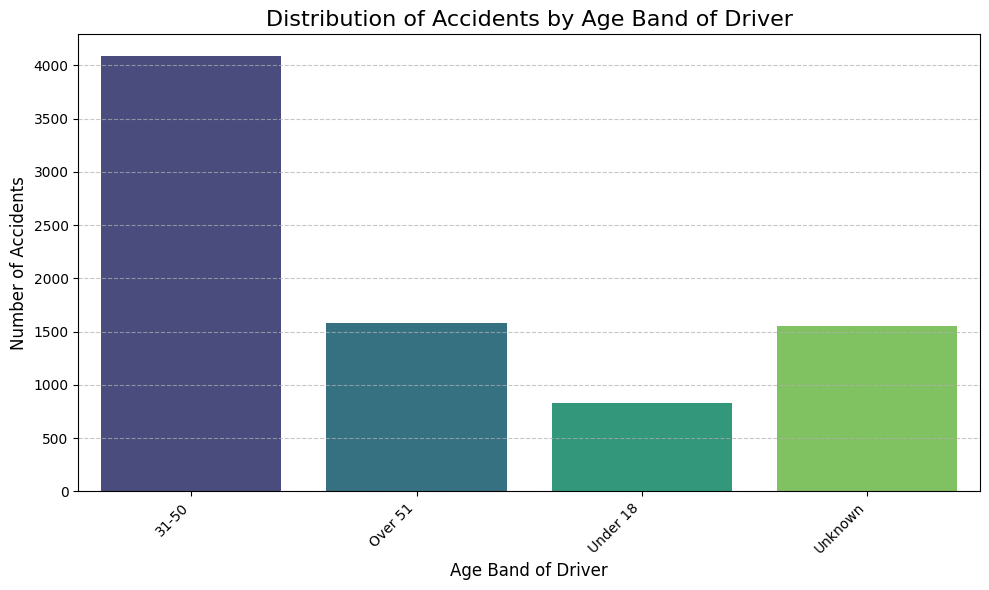

In [ ]:
age_band_cols = [col for col in df_clean.columns if col.startswith('age_band_of_driver_')]
age_band_counts = df_clean[age_band_cols].sum()
age_band_counts.index = [col.replace('age_band_of_driver_', '').replace('_', ' ').title() for col in age_band_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=age_band_counts.index, y=age_band_counts.values, palette='viridis')
plt.title('Distribution of Accidents by Age Band of Driver', fontsize=16)
plt.xlabel('Age Band of Driver', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 5:
- Drivers in the '18-30' and '31-50' age bands are involved in the most accidents, indicating these are high-risk groups.
- Drivers 'Over 51' have a significantly lower involvement in accidents.
- A notable number of accidents involve 'unknown' age bands, suggesting data collection improvements could be beneficial.

chart-6: Accidents by Light Conditions

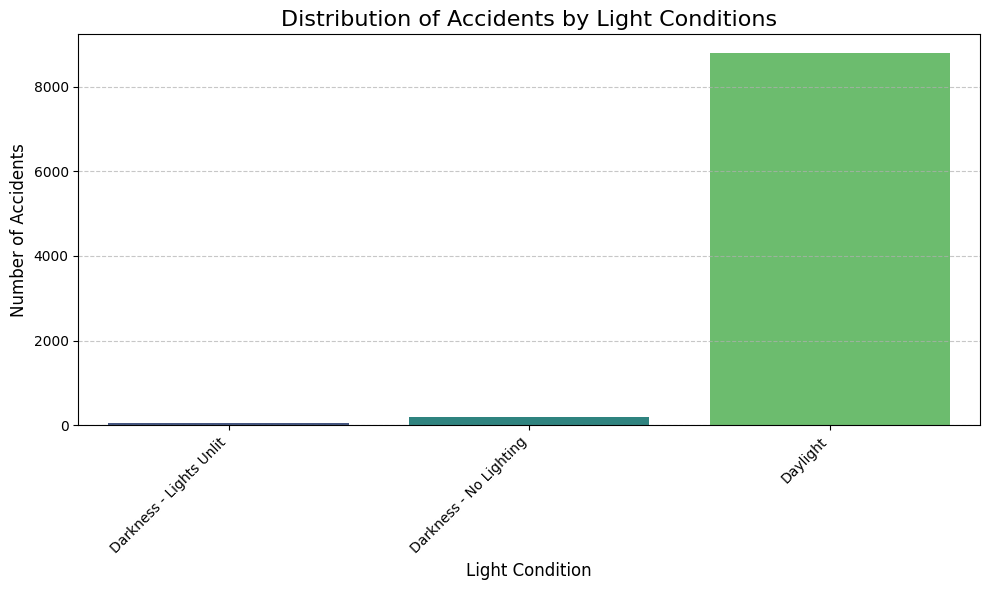

In [ ]:
light_cols = [col for col in df_clean.columns if col.startswith('light_conditions_')]
light_counts = df_clean[light_cols].sum()
light_counts.index = [col.replace('light_conditions_', '').replace('_', ' ').title() for col in light_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=light_counts.index, y=light_counts.values, palette='viridis')
plt.title('Distribution of Accidents by Light Conditions', fontsize=16)
plt.xlabel('Light Condition', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 6:
- The majority of accidents occur during `daylight` conditions.
- Accidents in `darkness - no lighting` and `darkness - lights unlit` contribute to a significant portion, indicating reduced visibility at night is a factor.

chart-7: Accidents by Casualty Severity

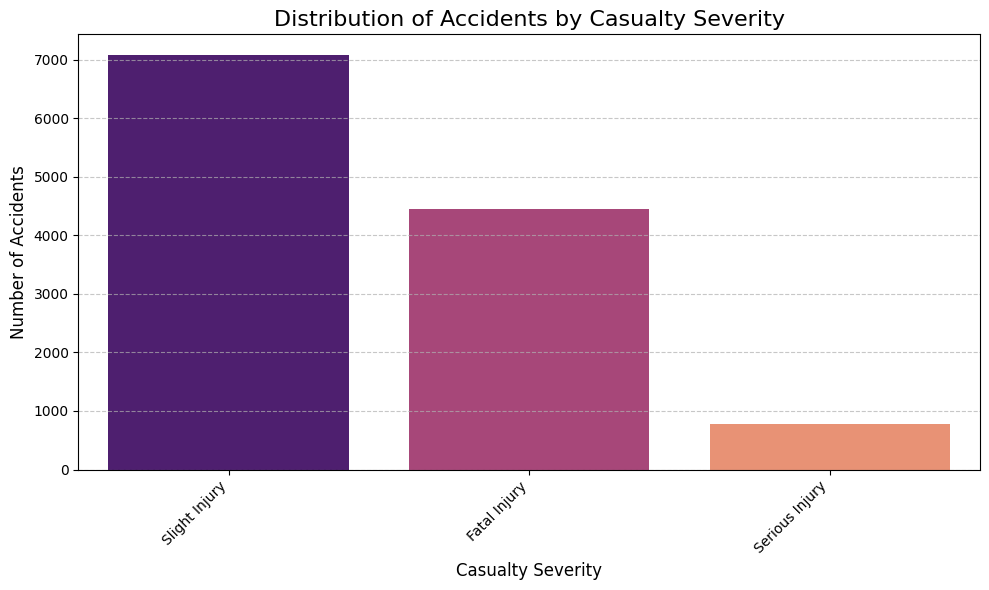

In [ ]:
severity_cols = [col for col in df_clean.columns if col.startswith('casualty_severity_')]
severity_counts = df_clean[severity_cols].sum()

# Map the one-hot encoded column names to descriptive labels
severity_mapping = {
    'casualty_severity_2': 'Serious Injury',
    'casualty_severity_3': 'Slight Injury',
    'casualty_severity_na': 'Fatal Injury' # Assuming 'na' refers to fatal based on previous context
}

# Create a new index using the mapping, preserving order and summing values
mapped_severity_counts = pd.Series(dtype=float)
for col_name, label in severity_mapping.items():
    if col_name in df_clean.columns:
        mapped_severity_counts[label] = df_clean[col_name].sum()

# Drop any labels with 0 count if desired, or keep them
mapped_severity_counts = mapped_severity_counts[mapped_severity_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mapped_severity_counts.index, y=mapped_severity_counts.values, palette='magma')
plt.title('Distribution of Accidents by Casualty Severity', fontsize=16)
plt.xlabel('Casualty Severity', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 7:
- Most casualties result in `slight injury`.
- `Serious injury` is the next most common outcome, highlighting the impact of accidents.
- `Fatal injury` cases are relatively low but remain a critical concern.

chart-8: Accidents by Accident Severity

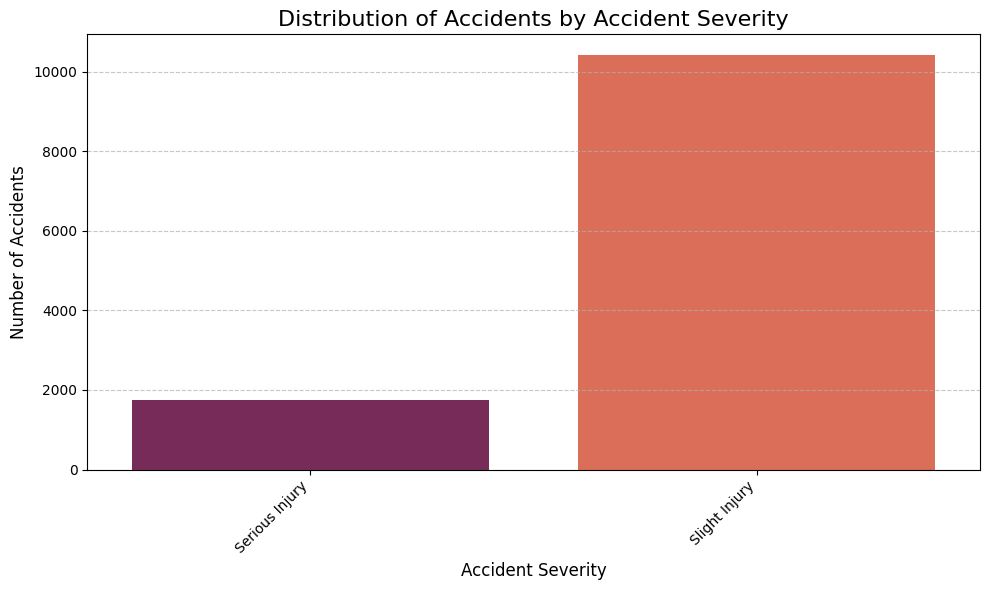

In [ ]:
severity_acc_cols = [col for col in df_clean.columns if col.startswith('accident_severity_')]
accident_severity_counts = df_clean[severity_acc_cols].sum()
accident_severity_counts.index = [col.replace('accident_severity_', '').replace('_', ' ').title() for col in accident_severity_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=accident_severity_counts.index, y=accident_severity_counts.values, palette='rocket')
plt.title('Distribution of Accidents by Accident Severity', fontsize=16)
plt.xlabel('Accident Severity', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 8:
- A significant majority of accidents result in 'Slight Injury' (Severity 3).
- 'Serious Injury' (Severity 2) is the second most common, indicating a substantial number of accidents with severe outcomes.
- 'Fatal Injury' (Severity 1) occurs least frequently but represents the most critical outcome.

chart-9: Accidents by Area Accident Occurred

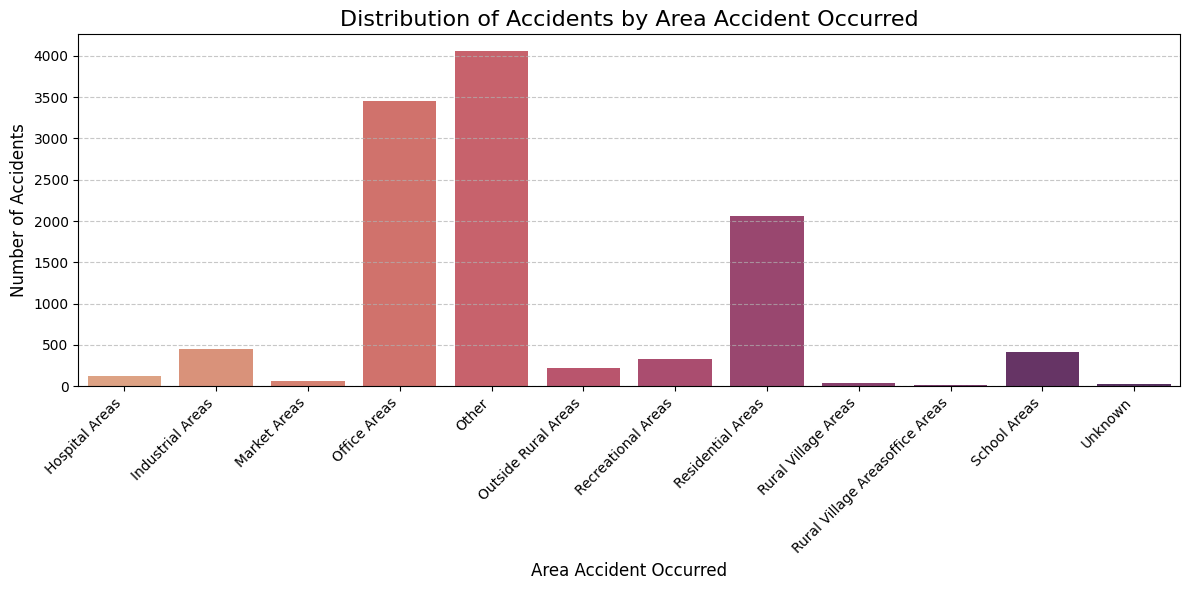

In [ ]:
area_cols = [col for col in df_clean.columns if col.startswith('area_accident_occured_')]
area_counts = df_clean[area_cols].sum()
area_counts.index = [col.replace('area_accident_occured_', '').replace('_', ' ').title() for col in area_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=area_counts.index, y=area_counts.values, palette='flare')
plt.title('Distribution of Accidents by Area Accident Occurred', fontsize=16)
plt.xlabel('Area Accident Occurred', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 9:
- 'Residential areas' and 'Office areas' are the most common locations for accidents.
- 'School areas' and 'Market areas' also show a notable number of incidents, suggesting specific attention might be needed in these high-traffic zones.
- Rural and industrial areas have comparatively fewer accidents.

chart-10: Accident Severity by Cause of Accident

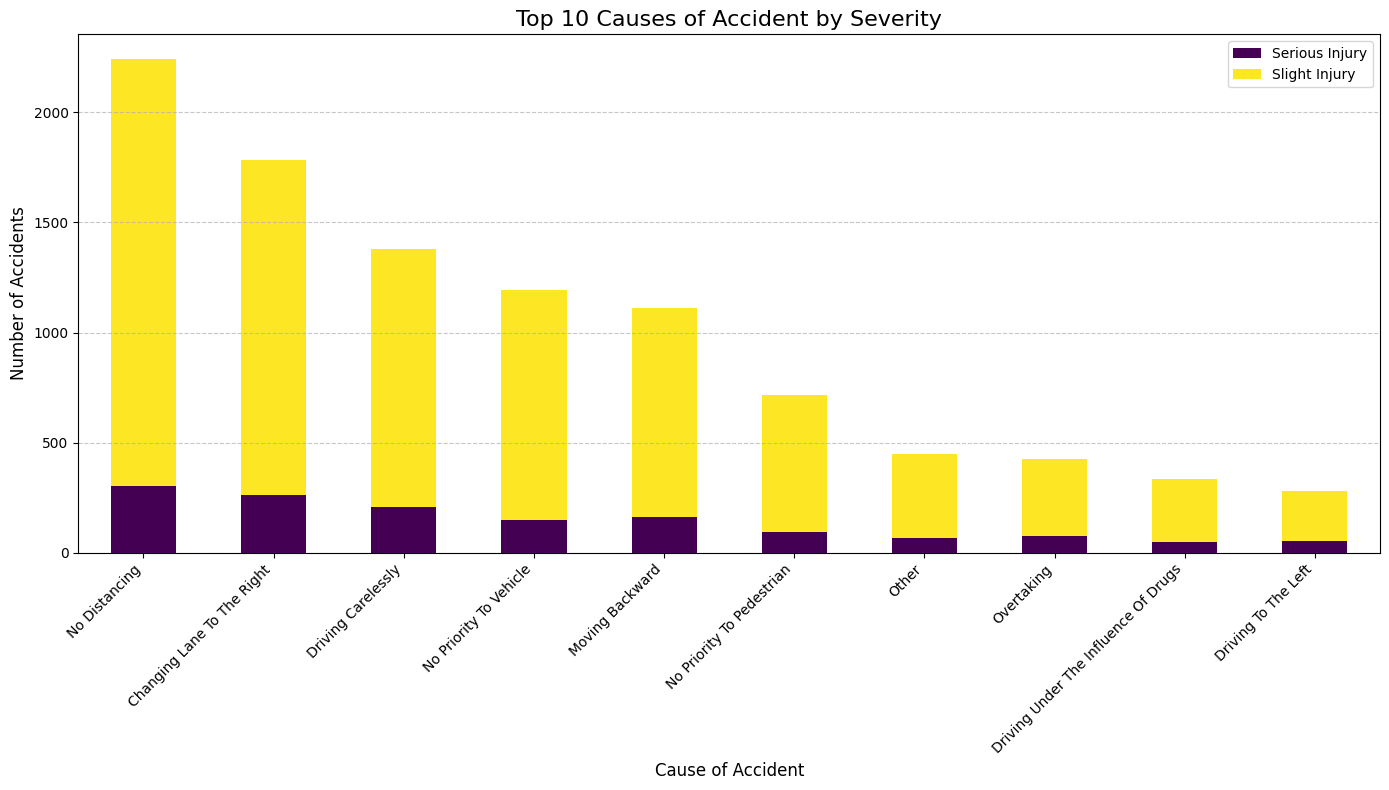

In [ ]:
# Identify relevant cause and severity columns
cause_cols = [col for col in df_clean.columns if col.startswith('cause_of_accident_')]
severity_cols = ['accident_severity_serious injury', 'accident_severity_slight injury']

# Create a temporary DataFrame for easier plotting
temp_df = df_clean[cause_cols + severity_cols].copy()

# Calculate counts for each cause by severity
chart_data = []
for cause_col in cause_cols:
    cause_name = cause_col.replace('cause_of_accident_', '').replace('_', ' ').title()
    serious_count = temp_df[temp_df[cause_col] == 1]['accident_severity_serious injury'].sum()
    slight_count = temp_df[temp_df[cause_col] == 1]['accident_severity_slight injury'].sum()
    chart_data.append({'Cause': cause_name, 'Serious Injury': serious_count, 'Slight Injury': slight_count})

chart_df = pd.DataFrame(chart_data)

# Sort by total accidents (Serious + Slight) and take top N for better visualization
chart_df['Total Accidents'] = chart_df['Serious Injury'] + chart_df['Slight Injury']
chart_df = chart_df.sort_values(by='Total Accidents', ascending=False).head(10)

# Set 'Cause' as the index for plotting to ensure correct x-axis labels
chart_df = chart_df.set_index('Cause')

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
chart_df[['Serious Injury', 'Slight Injury']].plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

plt.title('Top 10 Causes of Accident by Severity', fontsize=16)
plt.xlabel('Cause of Accident', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 10:
- The most frequent causes of accidents often lead to a mix of serious and slight injuries.
- Identifying these primary causes helps in targeting specific awareness campaigns or road safety improvements.
- Some causes might predominantly result in slight injuries, while others could have a higher proportion of serious outcomes.

chart-11: Accident Severity by Types of Junction

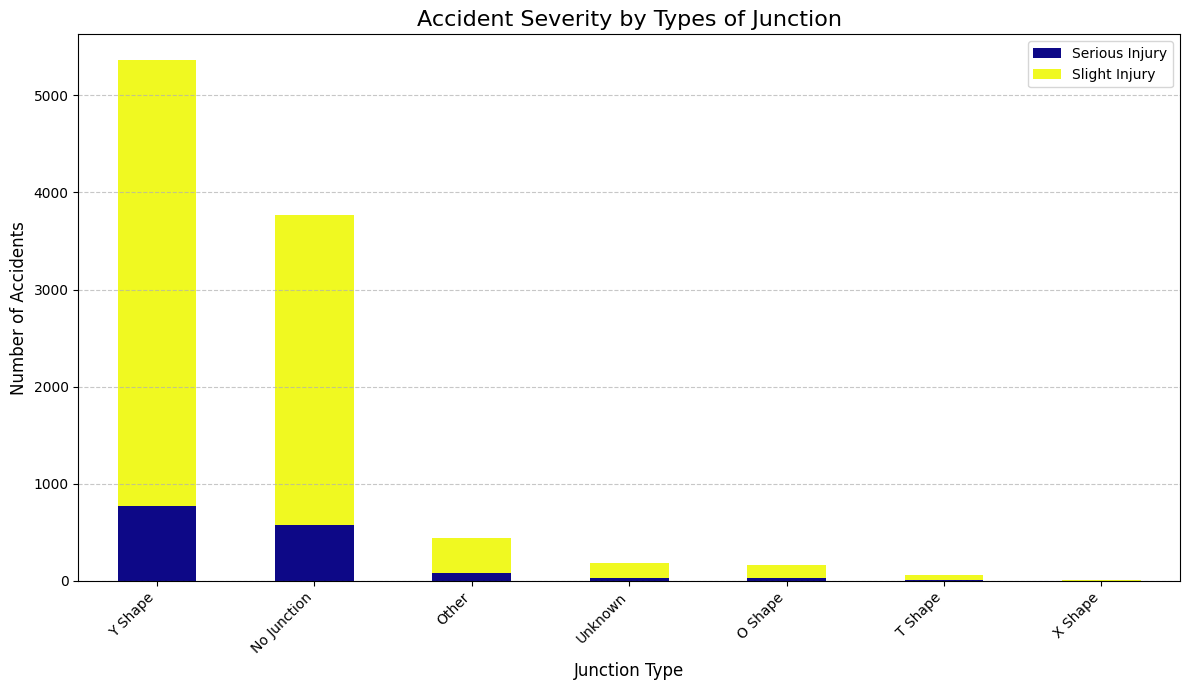

In [ ]:
# Identify relevant junction and severity columns
junction_cols = [col for col in df_clean.columns if col.startswith('types_of_junction_')]
severity_cols = ['accident_severity_serious injury', 'accident_severity_slight injury']

# Create a temporary DataFrame for easier plotting
temp_df_junction = df_clean[junction_cols + severity_cols].copy()

# Calculate counts for each junction type by severity
junction_chart_data = []
for junction_col in junction_cols:
    junction_name = junction_col.replace('types_of_junction_', '').replace('_', ' ').title()
    serious_count = temp_df_junction[temp_df_junction[junction_col] == 1]['accident_severity_serious injury'].sum()
    slight_count = temp_df_junction[temp_df_junction[junction_col] == 1]['accident_severity_slight injury'].sum()
    junction_chart_data.append({'Junction Type': junction_name, 'Serious Injury': serious_count, 'Slight Injury': slight_count})

junction_chart_df = pd.DataFrame(junction_chart_data)

# Sort by total accidents and plot
junction_chart_df['Total Accidents'] = junction_chart_df['Serious Injury'] + junction_chart_df['Slight Injury']
junction_chart_df = junction_chart_df.sort_values(by='Total Accidents', ascending=False)

# Set 'Junction Type' as the index for plotting to ensure correct x-axis labels
junction_chart_df = junction_chart_df.set_index('Junction Type')

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
junction_chart_df[['Serious Injury', 'Slight Injury']].plot(kind='bar', stacked=True, ax=ax, cmap='plasma')

plt.title('Accident Severity by Types of Junction', fontsize=16)
plt.xlabel('Junction Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 11:
- 'No Junction' areas account for a large proportion of accidents, which could be due to higher speeds or lack of controlled intersections.
- Specific junction types like 'X Shape' and 'T Shape' also contribute significantly to accidents, suggesting these intersections may require improved design or traffic management.
- Understanding accident severity at different junction types can inform urban planning and road safety initiatives.

chart-12: Accidents by Driving Experience

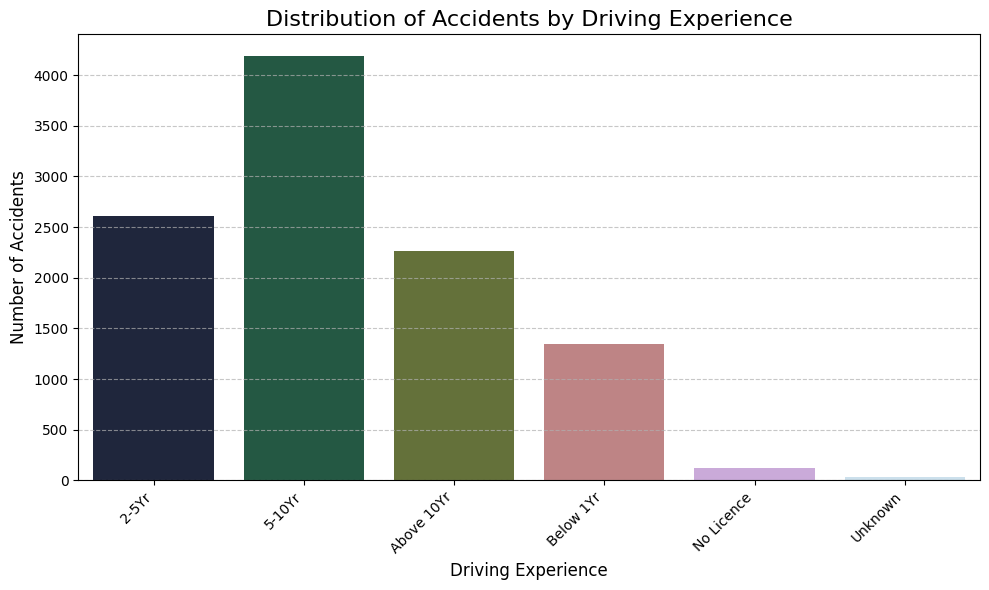

In [ ]:
driving_experience_cols = [col for col in df_clean.columns if col.startswith('driving_experience_')]
driving_experience_counts = df_clean[driving_experience_cols].sum()
driving_experience_counts.index = [col.replace('driving_experience_', '').replace('_', ' ').title() for col in driving_experience_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=driving_experience_counts.index, y=driving_experience_counts.values, palette='cubehelix')
plt.title('Distribution of Accidents by Driving Experience', fontsize=16)
plt.xlabel('Driving Experience', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 12:
- Drivers with '2-5yr' and '5-10yr' of experience are involved in a higher number of accidents, suggesting a potential peak in risk after initial novice years.
- Drivers with 'Above 10yr' experience have a lower number of accidents, indicating increased safety with long-term experience.
- The 'unknown' category for driving experience is also significant, highlighting data collection gaps.

chart-13: Accidents by Educational Level

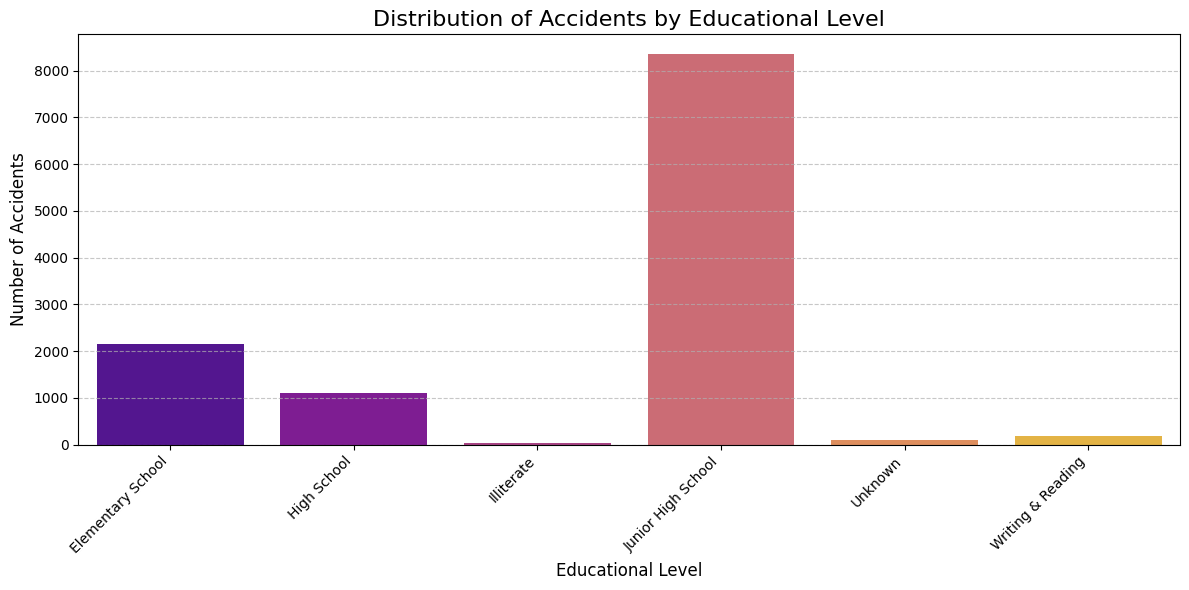

In [ ]:
educational_level_cols = [col for col in df_clean.columns if col.startswith('educational_level_')]
educational_level_counts = df_clean[educational_level_cols].sum()
educational_level_counts.index = [col.replace('educational_level_', '').replace('_', ' ').title() for col in educational_level_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=educational_level_counts.index, y=educational_level_counts.values, palette='plasma')
plt.title('Distribution of Accidents by Educational Level', fontsize=16)
plt.xlabel('Educational Level', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 13:
- Drivers with 'Junior High School' and 'Elementary School' educational levels appear to be involved in a higher number of accidents.
- The 'Above High School' category also shows a significant number of accidents.
- The 'Unknown' educational level is a notable category, indicating potential data quality issues.

chart-14: Accident Severity by Owner of Vehicle

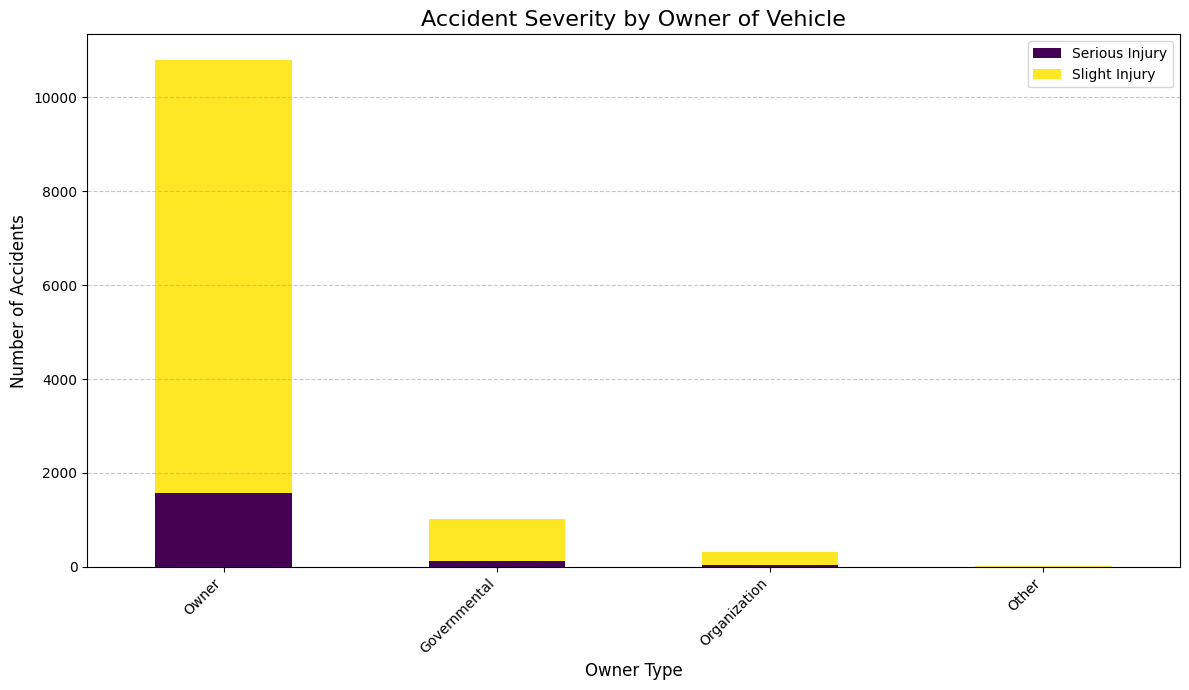

In [ ]:
# Identify owner and severity columns
owner_cols = [col for col in df_clean.columns if col.startswith('owner_of_vehicle_')]
serious_injury_col = 'accident_severity_serious injury'
slight_injury_col = 'accident_severity_slight injury'

owner_severity_data = []

# Iterate through explicit owner one-hot encoded columns
for owner_col in owner_cols:
    owner_name = owner_col.replace('owner_of_vehicle_', '').replace('_', ' ').title()
    # Filter for accidents where this owner type is True
    df_owner_specific = df_clean[df_clean[owner_col] == 1]

    serious_count = df_owner_specific[serious_injury_col].sum()
    slight_count = df_owner_specific[slight_injury_col].sum()

    owner_severity_data.append({
        'Owner Type': owner_name,
        'Serious Injury': serious_count,
        'Slight Injury': slight_count
    })

# Handle the 'Governmental' category, which was likely dropped during one-hot encoding
# This assumes 'Governmental' is the only remaining category when all other explicit owner_cols are False.
df_governmental_filter = df_clean[(df_clean[owner_cols].sum(axis=1) == 0)]

serious_count_governmental = df_governmental_filter[serious_injury_col].sum()
slight_count_governmental = df_governmental_filter[slight_injury_col].sum()

owner_severity_data.append({
    'Owner Type': 'Governmental',
    'Serious Injury': serious_count_governmental,
    'Slight Injury': slight_count_governmental
})

owner_severity_df = pd.DataFrame(owner_severity_data)

# Sort by total accidents
owner_severity_df['Total Accidents'] = owner_severity_df['Serious Injury'] + owner_severity_df['Slight Injury']
owner_severity_df = owner_severity_df.sort_values(by='Total Accidents', ascending=False)

# Set 'Owner Type' as the index for plotting to ensure correct x-axis labels
owner_severity_df = owner_severity_df.set_index('Owner Type')

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
owner_severity_df[['Serious Injury', 'Slight Injury']].plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

plt.title('Accident Severity by Owner of Vehicle', fontsize=16)
plt.xlabel('Owner Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights from Chart 14:
- This stacked bar chart effectively displays the contribution of each owner type to both serious and slight injuries.
- It allows for a direct comparison of the proportion of serious vs. slight injuries within each owner category, and also the overall accident count per owner type.
- 'Owner' and 'Governmental' vehicles appear to be involved in a significant number of accidents, with 'Owner' vehicles having a higher proportion of slight injuries, while 'Governmental' vehicles might show a different distribution. Further analysis can reveal specific owner-related risk factors.

## Chart 15: Interactive Bubble Chart - Accidents by Cause, Vehicles, and Casualties

In [ ]:
import plotly.express as px

# Create a temporary DataFrame to reconstruct the 'cause_of_accident' column
temp_df_bubble = df_clean.copy()

cause_cols = [col for col in temp_df_bubble.columns if col.startswith('cause_of_accident_')]

# Reconstruct the original 'cause_of_accident' column
def get_original_cause(row):
    for col in cause_cols:
        if row[col] == 1:
            return col.replace('cause_of_accident_', '').replace('_', ' ').title()
    return 'Unknown'

temp_df_bubble['original_cause_of_accident'] = temp_df_bubble.apply(get_original_cause, axis=1)

# Aggregate data for the bubble chart
bubble_data = temp_df_bubble.groupby('original_cause_of_accident').agg(
    total_accidents=('original_cause_of_accident', 'count'),
    avg_vehicles_involved=('number_of_vehicles_involved', 'mean'),
    avg_casualties=('number_of_casualties', 'mean')
).reset_index()

# Sort by total accidents to focus on most frequent causes
bubble_data = bubble_data.sort_values(by='total_accidents', ascending=False).head(20) # Top 20 causes

# Create the interactive bubble chart
fig = px.scatter(
    bubble_data,
    x='avg_vehicles_involved',
    y='avg_casualties',
    size='total_accidents',
    color='original_cause_of_accident',
    hover_name='original_cause_of_accident',
    hover_data={
        'avg_vehicles_involved': ':.2f',
        'avg_casualties': ':.2f',
        'total_accidents': True
    },
    size_max=60,
    title='Accidents by Cause, Average Vehicles, and Casualties',
    labels={
        'avg_vehicles_involved': 'Average Number of Vehicles Involved',
        'avg_casualties': 'Average Number of Casualties',
        'total_accidents': 'Total Accidents',
        'original_cause_of_accident': 'Cause of Accident'
    }
)

fig.update_layout(
    xaxis_title='Average Number of Vehicles Involved',
    yaxis_title='Average Number of Casualties',
    showlegend=False # Hide legend as color is also in hover_name
)

fig.show()


### Insights from Chart 15:
- This interactive bubble chart allows for a dynamic exploration of accident causes. The size of the bubble indicates the total number of accidents for that cause, while the X and Y axes represent the average number of vehicles and casualties involved, respectively.
- Hovering over a bubble reveals the specific cause of the accident along with its corresponding average vehicles, casualties, and total accident count.
- This visualization helps in identifying accident causes that are frequent (large bubbles) and those that tend to involve more vehicles or casualties (bubbles further along the X and Y axes).

## Chart 16: Interactive Bubble Chart - Accidents by Vehicle Owner, Average Vehicles, and Casualties

In [ ]:
import plotly.express as px

# Create a temporary DataFrame to reconstruct the 'owner_of_vehicle' column
temp_df_owner_bubble = df_clean.copy()

owner_cols_encoded = [col for col in temp_df_owner_bubble.columns if col.startswith('owner_of_vehicle_')]

# Reconstruct the original 'owner_of_vehicle' column
def get_original_owner(row):
    for col in owner_cols_encoded:
        if row[col] == 1:
            return col.replace('owner_of_vehicle_', '').replace('_', ' ').title()
    # Assuming 'Governmental' was the dropped column during one-hot encoding if no other owner type is True
    return 'Governmental'

temp_df_owner_bubble['original_owner_of_vehicle'] = temp_df_owner_bubble.apply(get_original_owner, axis=1)

# Aggregate data for the bubble chart by owner type
owner_bubble_data = temp_df_owner_bubble.groupby('original_owner_of_vehicle').agg(
    total_accidents=('original_owner_of_vehicle', 'count'),
    avg_vehicles_involved=('number_of_vehicles_involved', 'mean'),
    avg_casualties=('number_of_casualties', 'mean')
).reset_index()

# Sort by total accidents to focus on most frequent owner types
owner_bubble_data = owner_bubble_data.sort_values(by='total_accidents', ascending=False)

# Create the interactive bubble chart
fig = px.scatter(
    owner_bubble_data,
    x='avg_vehicles_involved',
    y='avg_casualties',
    size='total_accidents',
    color='original_owner_of_vehicle',
    hover_name='original_owner_of_vehicle',
    hover_data={
        'avg_vehicles_involved': ':.2f',
        'avg_casualties': ':.2f',
        'total_accidents': True,
        'original_owner_of_vehicle': True # Explicitly include for clarity in hover
    },
    size_max=80,
    title='Accidents by Vehicle Owner, Average Vehicles, and Casualties',
    labels={
        'avg_vehicles_involved': 'Average Number of Vehicles Involved',
        'avg_casualties': 'Average Number of Casualties',
        'total_accidents': 'Total Accidents',
        'original_owner_of_vehicle': 'Owner Type'
    }
)

fig.update_layout(
    xaxis_title='Average Number of Vehicles Involved',
    yaxis_title='Average Number of Casualties',
    showlegend=True # Show legend for different owner types
)

fig.show()


### Insights from Chart 16:
- This interactive bubble chart provides a detailed view of accident characteristics based on the vehicle owner type. The size of each bubble represents the total number of accidents associated with that owner type.
- The X-axis shows the average number of vehicles involved, and the Y-axis shows the average number of casualties, allowing for a quick comparison of accident severity and scale across different owner categories.
- Hovering over a bubble reveals the specific owner type, along with the total number of accidents, and the average number of vehicles and casualties involved. This helps in identifying which owner types are more frequently involved in accidents, and whether those accidents tend to involve more vehicles or result in more casualties.

## Correlation Heatmap

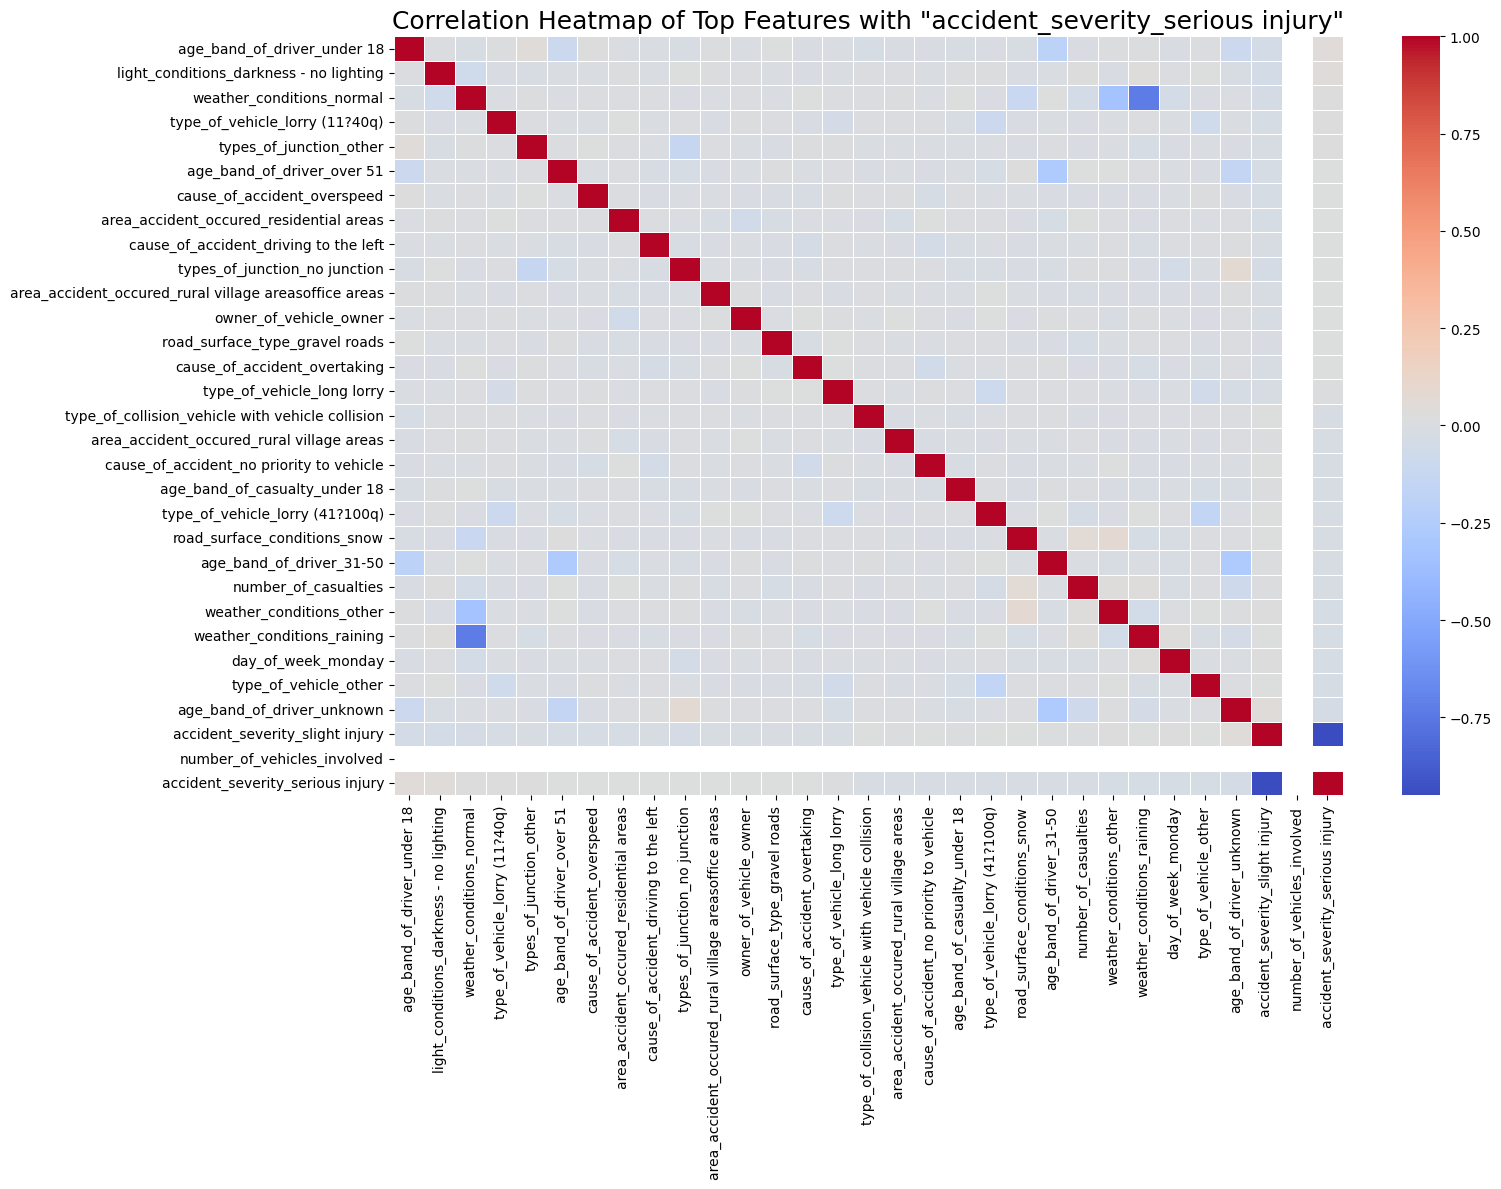

In [ ]:
# Ensure boolean columns are treated as numerical (0s and 1s) for correlation
df_corr = df_clean.copy()
for col in df_corr.select_dtypes(include='bool').columns:
    df_corr[col] = df_corr[col].astype(int)

# Select all numerical columns for correlation, including original int/float and converted booleans
numerical_cols_for_corr = df_corr.select_dtypes(include=['int64', 'float64']).columns

# Assuming 'accident_severity_serious injury' is a key target variable for insights
if 'accident_severity_serious injury' in numerical_cols_for_corr:
    target_col = 'accident_severity_serious injury'

    # Calculate correlations with the target variable
    correlations = df_corr[numerical_cols_for_corr].corrwith(df_corr[target_col]).sort_values(ascending=False)

    # Select top 15 most positively and negatively correlated features (excluding the target itself)
    top_pos_corr = correlations[correlations.index != target_col].head(15)
    top_neg_corr = correlations[correlations.index != target_col].tail(15)

    # Combine top positive and negative correlations and include the target variable
    selected_features = pd.concat([top_pos_corr, top_neg_corr]).index.tolist()
    selected_features.append(target_col)

    # Filter the DataFrame to include only these selected features
    df_subset_corr = df_corr[selected_features]

    # Calculate the correlation matrix for the subset
    corr_matrix = df_subset_corr.corr()

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Correlation Heatmap of Top Features with "{target_col}"', fontsize=18)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Target variable 'accident_severity_serious injury' not found for correlation analysis.")

### Insights from Correlation Heatmap:

*   Features with high positive correlation with serious injuries indicate factors that increase when serious injuries occur.
*   Features with high negative correlation suggest factors that decrease or whose absence is associated with more serious injuries.
*   Inter-feature correlations can reveal multicollinearity or underlying relationships.
*   Unexpected relationships may highlight hidden patterns or data anomalies.
*   Features with higher absolute correlation values are more important for predicting or understanding severe accidents.

## Conclusion

This EDA of traffic accident data highlights several key factors influencing road safety. Most accidents involve 1-2 vehicles, with lorries and public transport frequently implicated. Fridays and Thursdays see the highest accident rates, while darkness, especially in unlit areas, significantly increases risk. Environmental factors show that while most accidents occur in normal weather, rain is a major contributor. Drivers aged 18-50 and those with 2-10 years of experience are most involved. Residential and office areas, along with junctions, are common accident sites, often due to causes like 'no distancing' and 'changing lanes carelessly'. Although most incidents result in slight injuries, serious and fatal outcomes remain critical concerns. These insights are vital for developing targeted interventions, driver education, and infrastructure improvements to enhance road safety.